In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sbn

In [62]:
# Importa dataset
dataset = pd.read_csv("https://raw.githubusercontent.com/joaovictorlopezpereira/Heart-Failure-Predictor/refs/heads/main/csvs/heart-before-treatment.csv")

In [63]:
# Imprime dataset
display(dataset)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [64]:
# Remove linhas com algum valor NaN em seus atributos
dataset.dropna()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [65]:
# Mostra se há alguma coluna com elemento nulo no dataset
dataset.isnull().any()

,0
Age,False
Sex,False
ChestPainType,False
RestingBP,False
Cholesterol,False
FastingBS,False
RestingECG,False
MaxHR,False
ExerciseAngina,False
Oldpeak,False


In [66]:
# Mostra se há alguma linha duplicada no dataset
dataset.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
913,False
914,False
915,False
916,False


In [67]:
# Mede algumas métricas estatísticas de cada atributo numérico
dataset.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [68]:
# Imprime quantas classificações cada coluna não-binária tem
print(dataset['ChestPainType'].nunique())
print(dataset['ST_Slope'].nunique())
print(dataset['RestingECG'].nunique())
print(dataset['ExerciseAngina'].nunique())
print(dataset['Sex'].nunique())

4
3
3
2
2


In [69]:
# Para as colunas com classificações binárias, trocamos para 0 e 1
dataset['Sex'] = dataset['Sex'].replace({'F': 0, 'M': 1})
dataset['ExerciseAngina'] = dataset['ExerciseAngina'].replace({'N': 0, 'Y': 1})

# Para colunas com classificações não-binárias, usando hot-encoding
dataset = pd.get_dummies(dataset, columns=['ChestPainType', 'ST_Slope', 'RestingECG'])
dataset = dataset.astype(int)

/tmp/ipython-input-437590182.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['Sex'] = dataset['Sex'].replace({'F': 0, 'M': 1})
/tmp/ipython-input-437590182.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['ExerciseAngina'] = dataset['ExerciseAngina'].replace({'N': 0, 'Y': 1})


In [70]:
# Imprime dataset atualizado
display(dataset)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0,0,0,1,0,0,0,0,1,0,1,0
1,49,0,160,180,0,156,0,1,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0,0,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1,1,0,0,0,1,0,1,0,0,1,0
914,68,1,144,193,1,141,0,3,1,1,0,0,0,0,1,0,0,1,0
915,57,1,130,131,0,115,1,1,1,1,0,0,0,0,1,0,0,1,0
916,57,0,130,236,0,174,0,0,1,0,1,0,0,0,1,0,1,0,0


array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'Sex'}>,
        <Axes: title={'center': 'RestingBP'}>,
        <Axes: title={'center': 'Cholesterol'}>],
       [<Axes: title={'center': 'FastingBS'}>,
        <Axes: title={'center': 'MaxHR'}>,
        <Axes: title={'center': 'ExerciseAngina'}>,
        <Axes: title={'center': 'Oldpeak'}>],
       [<Axes: title={'center': 'HeartDisease'}>,
        <Axes: title={'center': 'ChestPainType_ASY'}>,
        <Axes: title={'center': 'ChestPainType_ATA'}>,
        <Axes: title={'center': 'ChestPainType_NAP'}>],
       [<Axes: title={'center': 'ChestPainType_TA'}>,
        <Axes: title={'center': 'ST_Slope_Down'}>,
        <Axes: title={'center': 'ST_Slope_Flat'}>,
        <Axes: title={'center': 'ST_Slope_Up'}>],
       [<Axes: title={'center': 'RestingECG_LVH'}>,
        <Axes: title={'center': 'RestingECG_Normal'}>,
        <Axes: title={'center': 'RestingECG_ST'}>, <Axes: >]],
      dtype=object)

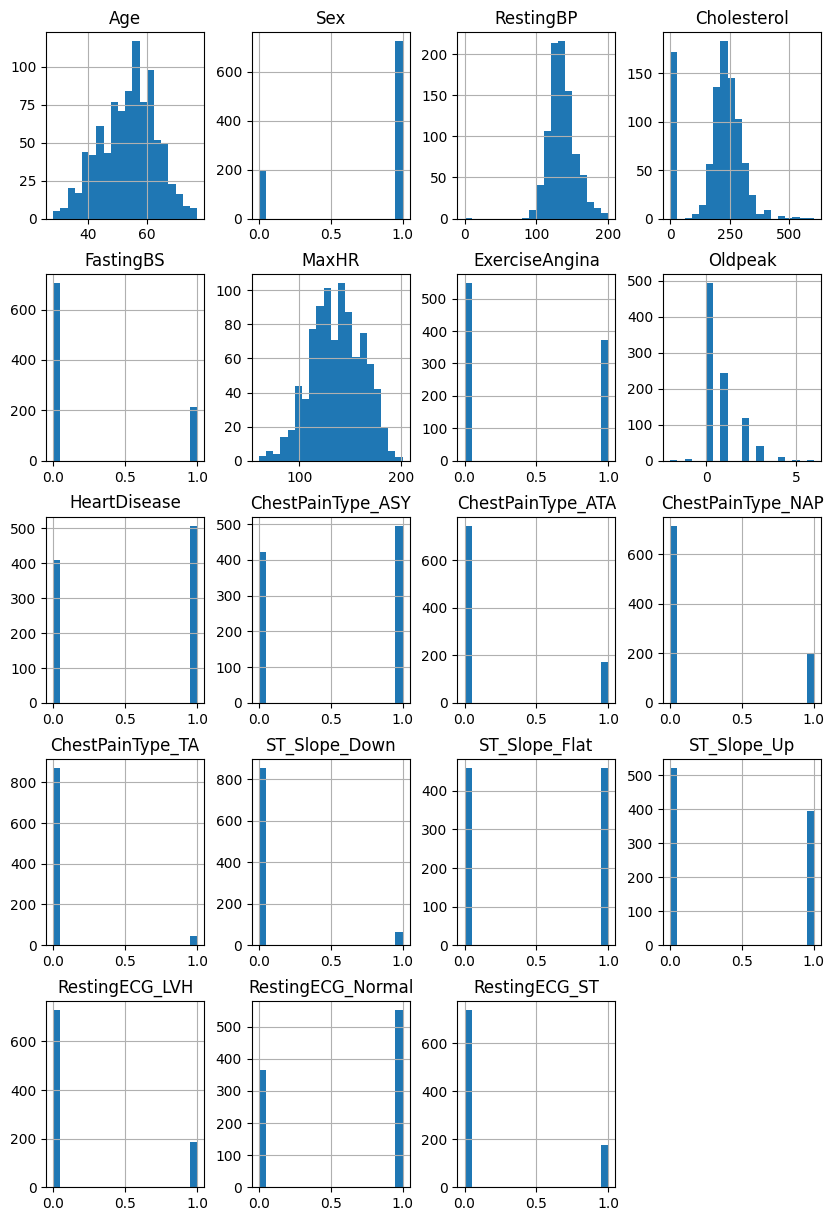

In [71]:
# Imprime histograma de cada coluna do dataset para podermos observar a distribuição dos dados
dataset.hist(figsize=(10, 15), bins=20)

In [72]:
# Analisa outliers
def calcula_zscore(coluna):
  std_duration = np.std(coluna)
  z_score = (coluna.values-np.mean(coluna))/std_duration
  return z_score

# Remove dados que estão, em módulo, acima de 3 desvios padrões
def remove_outliers(coluna):
  z_score = calcula_zscore(coluna)
  number_of_outliers = 0
  for i in range(len(z_score)):
      if (abs(z_score[i]) > 3):
          number_of_outliers = number_of_outliers + 1
          #print(z_score[i])
          dataset.drop(i, inplace=True)
          # display(dataset.loc[i])
  print(number_of_outliers)
remove_outliers(dataset.RestingBP)

# TODO: Testar depois eliminando *todos* os outliers de todas as features numéricas


8


In [73]:
# Remove a coluna Cholesterol
# Decidimos que essa escolha seria válida pois há diversos casos
# (em sua maioria, que apresentam doença cardíaca) que estão com
# valor de Cholesterol nulo, bem como casos onde o valor de
# Cholesterol está muito alto. Sendo assim, decidimos, por conta
# dessa estranheza no dataset, não trabalhar com essa feature
#dataset = dataset.drop(columns=['Cholesterol'])

# Remover as linhas cujo Cholesterol é nulo
dataset = dataset[dataset['Cholesterol'] != 0]



array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'Sex'}>,
        <Axes: title={'center': 'RestingBP'}>,
        <Axes: title={'center': 'Cholesterol'}>],
       [<Axes: title={'center': 'FastingBS'}>,
        <Axes: title={'center': 'MaxHR'}>,
        <Axes: title={'center': 'ExerciseAngina'}>,
        <Axes: title={'center': 'Oldpeak'}>],
       [<Axes: title={'center': 'HeartDisease'}>,
        <Axes: title={'center': 'ChestPainType_ASY'}>,
        <Axes: title={'center': 'ChestPainType_ATA'}>,
        <Axes: title={'center': 'ChestPainType_NAP'}>],
       [<Axes: title={'center': 'ChestPainType_TA'}>,
        <Axes: title={'center': 'ST_Slope_Down'}>,
        <Axes: title={'center': 'ST_Slope_Flat'}>,
        <Axes: title={'center': 'ST_Slope_Up'}>],
       [<Axes: title={'center': 'RestingECG_LVH'}>,
        <Axes: title={'center': 'RestingECG_Normal'}>,
        <Axes: title={'center': 'RestingECG_ST'}>, <Axes: >]],
      dtype=object)

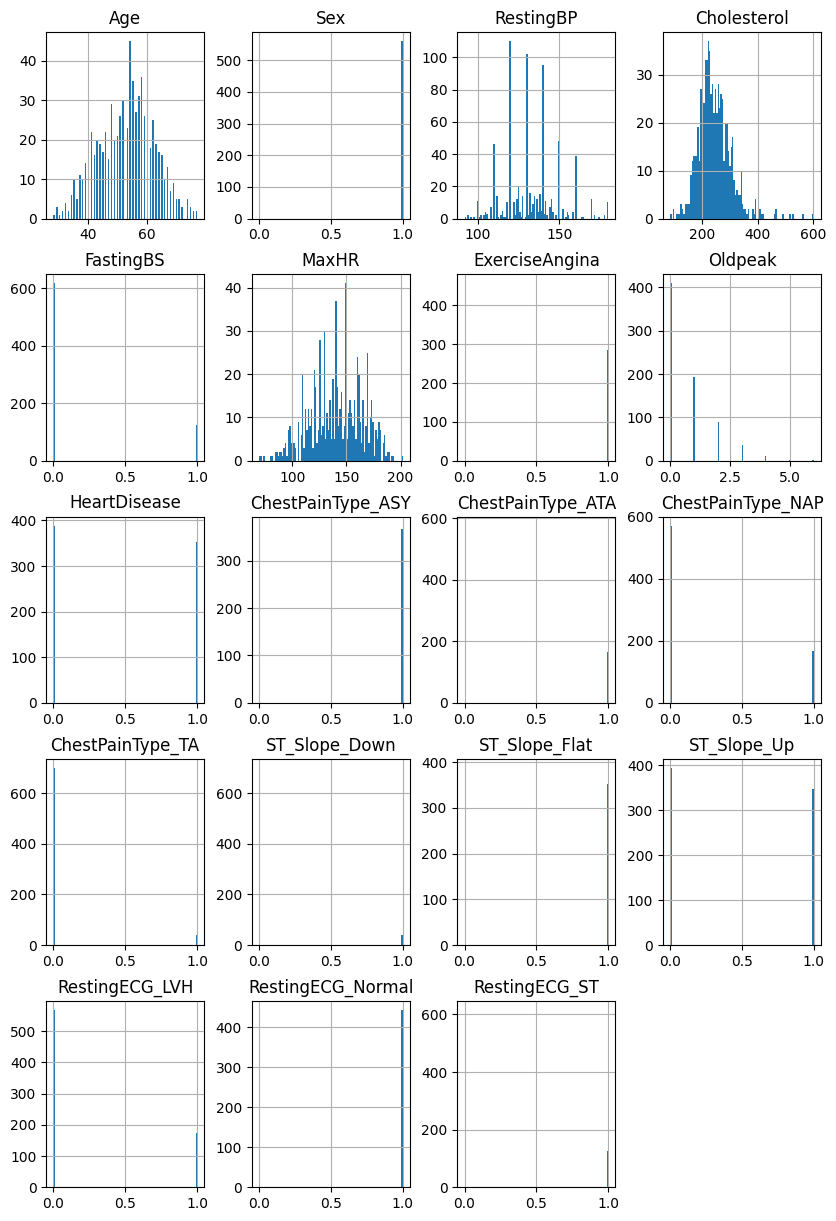

In [74]:
# Verifica se os dados estão razoavelmente balanceados
dataset.hist(figsize=(10, 15), bins=100)

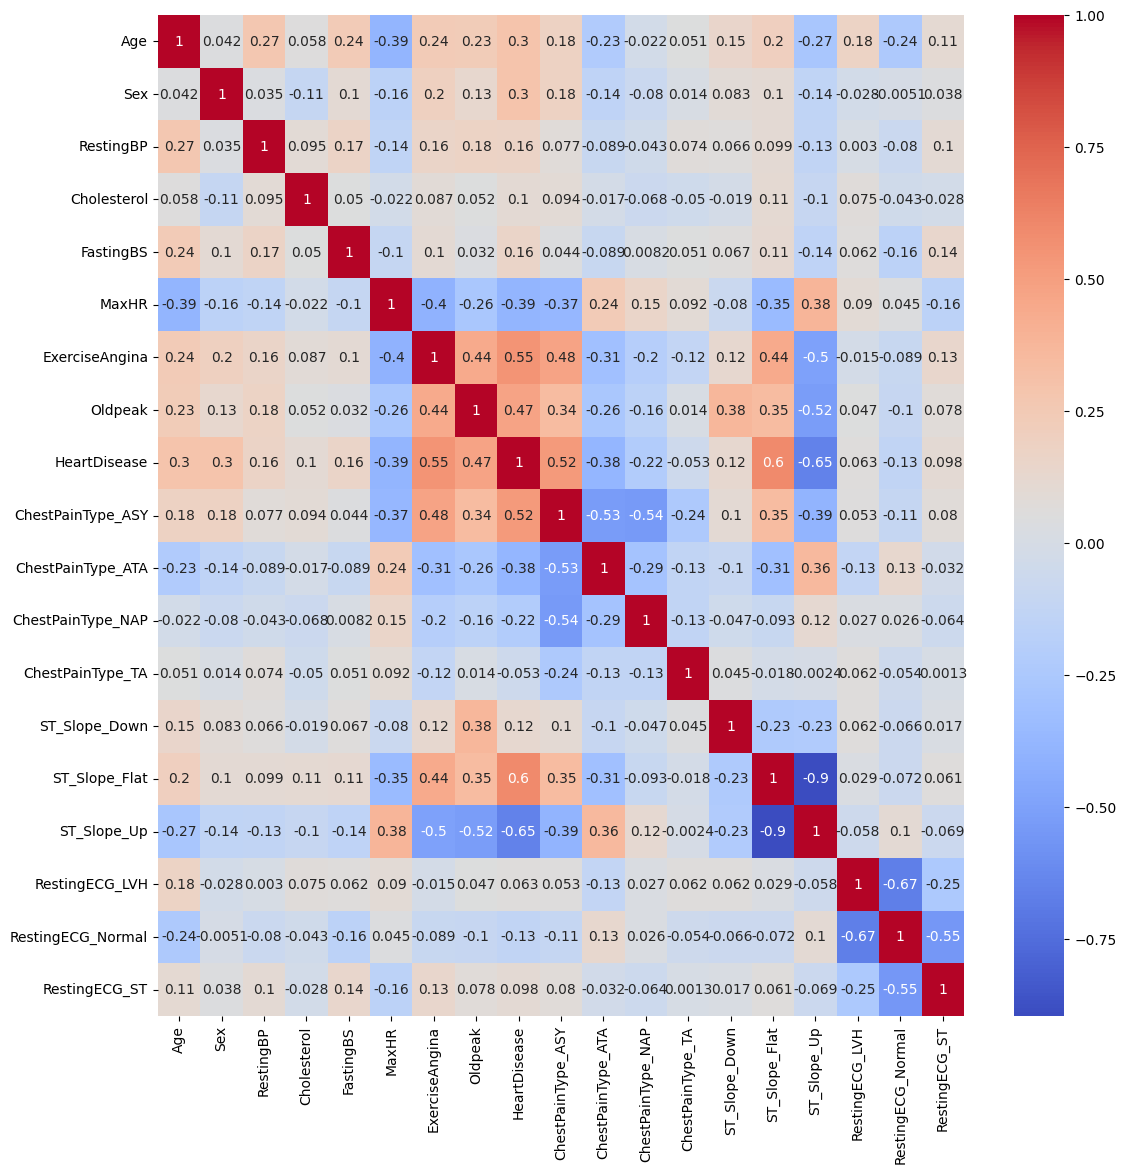

In [75]:
cor_pearson = dataset.corr('pearson')
plt.figure(figsize=(13, 13))
sbn.heatmap(cor_pearson, annot=True, cmap='coolwarm')
plt.show()

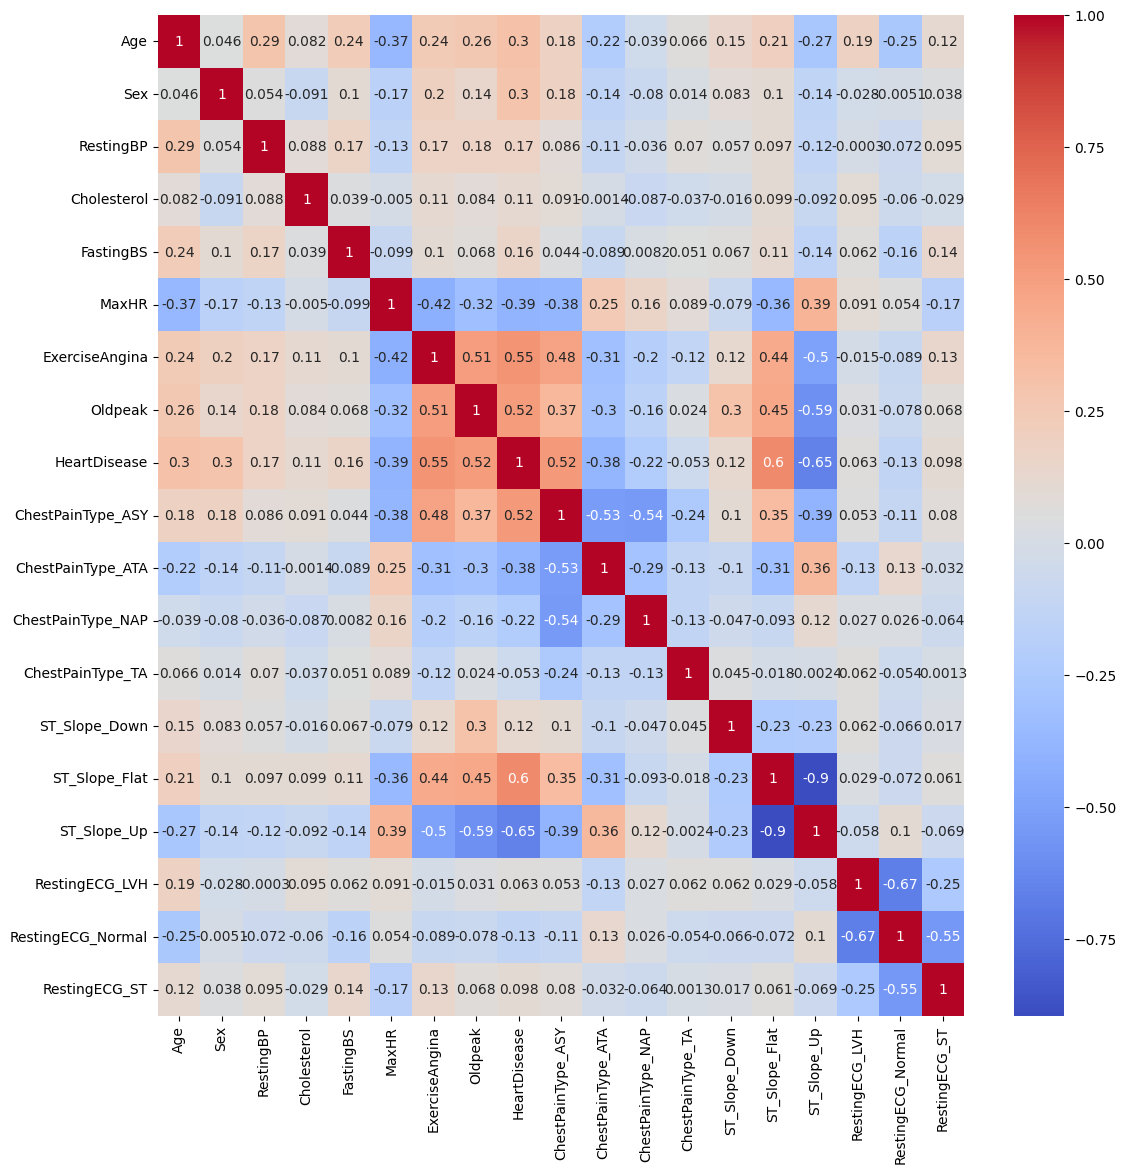

In [76]:
cor_spearman = dataset.corr('spearman')
plt.figure(figsize=(13, 13))
sbn.heatmap(cor_spearman, annot=True, cmap='coolwarm')
plt.show()

In [77]:
# Remove colunas pouco correlacionadas com a variável target (ou muito correlacionada com outra que tem aula correlação com a target)
dataset = dataset.drop(columns=['ST_Slope_Flat'])
dataset = dataset.drop(columns=['RestingECG_LVH'])
dataset = dataset.drop(columns=['RestingECG_Normal'])

In [78]:
display(dataset)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ST_Slope_Down,ST_Slope_Up,RestingECG_ST
0,40,1,140,289,0,172,0,0,0,0,1,0,0,0,1,0
1,49,0,160,180,0,156,0,1,1,0,0,1,0,0,0,0
2,37,1,130,283,0,98,0,0,0,0,1,0,0,0,1,1
3,48,0,138,214,0,108,1,1,1,1,0,0,0,0,0,0
4,54,1,150,195,0,122,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1,1,0,0,0,1,0,0,0
914,68,1,144,193,1,141,0,3,1,1,0,0,0,0,0,0
915,57,1,130,131,0,115,1,1,1,1,0,0,0,0,0,0
916,57,0,130,236,0,174,0,0,1,0,1,0,0,0,0,0


In [79]:
# Salva csv após tratamento dos dados
dataset.to_csv("heart_treated.csv", index=False)